In [ ]:
#importo las librerias que voy a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#Consigna 1

In [ ]:
#descargo el archivo y veo que forma tiene el dataframe, su cantidad de filas, columnas y el tipo de datos que tienen
!wget "http://users.df.uba.ar/hgrecco/tmp/tp2/viviendasArg.csv" #uso el del parcial
df_casas = pd.read_csv("viviendasArg.csv",encoding="latin-1") #con el default no me cargaba y con windom 1252 tampoco
print(df_casas.shape)
df_casas.head()

--2025-06-13 01:02:55--  http://users.df.uba.ar/hgrecco/tmp/tp2/viviendasArg.csv
Resolving users.df.uba.ar (users.df.uba.ar)... 157.92.11.118
Connecting to users.df.uba.ar (users.df.uba.ar)|157.92.11.118|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8522150 (8.1M) [text/csv]
Saving to: ‘viviendasArg.csv’

viviendasArg.csv    100%[===================>]   8.13M  3.01MB/s    in 2.7s    

2025-06-13 01:02:59 (3.01 MB/s) - ‘viviendasArg.csv’ saved [8522150/8522150]

(74714, 12)


,Unnamed: 0,tipo,ciudad,provincia,lat,lon,precioUSD,sup_tot,sup_cub,precio_sup_tot,precio_sup_cub,ambientes
0,1,PH,Mataderos,Capital Federal,-34.661824,-58.508839,62000.0,55.0,40,1127.272727,1550.000000,NaN
1,2,departamento,Mataderos,Capital Federal,-34.652262,-58.522982,72000.0,55.0,55,1309.090909,1309.090909,NaN
2,3,departamento,Centro,Buenos Aires Costa AtlÃ¡ntica,-38.002626,-57.549447,64000.0,35.0,35,1828.571429,1828.571429,NaN
3,4,PH,Munro,Bs.As. G.B.A. Zona Norte,-34.532957,-58.521783,130000.0,106.0,78,1226.415094,1666.666667,NaN
4,5,departamento,Belgrano,Capital Federal,-34.559873,-58.443362,138000.0,45.0,40,3066.666667,3450.000000,NaN


##Exploracion y curaduria

In [ ]:
print(df_casas.describe()) #exploro los datos
print(df_casas.info())
##inicialmente tengo 74714 datos de propiedades en total

         Unnamed: 0           lat           lon     precioUSD        sup_tot  \
count  74714.000000  44810.000000  44810.000000  7.471400e+04   54053.000000   
mean   37357.500000    -34.853436    -58.781135  2.565630e+05     222.344976   
std    21568.218343      1.478159      1.656583  2.979220e+05    1543.936185   
min        1.000000    -54.801452    -71.665143  5.000000e+03      10.000000   
25%    18679.250000    -34.654005    -58.585955  1.050000e+05      52.000000   
50%    37357.500000    -34.600349    -58.459580  1.650000e+05      90.000000   
75%    56035.750000    -34.540979    -58.394489  2.950000e+05     211.000000   
max    74714.000000    -24.185786    -54.560043  8.500000e+06  200000.000000   

            sup_cub  precio_sup_tot  precio_sup_cub     ambientes  
count  74714.000000    54053.000000    7.471200e+04  32926.000000  
mean     119.113044     2270.484157    3.222467e+03      3.020986  
std      107.869479     3000.391155    1.635549e+04      1.697490  
min    

Veo que hay varios datos que faltan, por ejemplo en lat y long hay 44810 datos en vez de 74714, y en ambientes faltan casi la mitad de los datos.

In [ ]:
df_casas['provincia'].value_counts() #veo como es la distribucion de datos por provincia

,count
provincia,
Capital Federal,25120
Bs.As. G.B.A. Zona Norte,20918
Bs.As. G.B.A. Zona Sur,9230
Buenos Aires Costa AtlÃ¡ntica,6453
Bs.As. G.B.A. Zona Oeste,5921
CÃ³rdoba,3155
Santa Fe,1395
Buenos Aires Interior,1231
Corrientes,406


veo que hay muchos mas datos de caba y amba que del resto del pais

In [ ]:
#veo que hay varias provincias mal escritas, veo el resto de objets en el df
df_casas['ciudad'].unique()#aca algunas ciudades tienen errores
df_casas['tipo'].unique()#aca estan bien
##corrijo el nombre de las provincias

correcciones_provincias = {
    'Buenos Aires Costa AtlÃ¡ntica': 'Buenos Aires Costa Atlántica',
    'CÃ³rdoba': 'Córdoba',
    'RÃ­o Negro': 'Río Negro',
    'NeuquÃ©n': 'Neuquén',
    'Misiones': 'Misiones',
    'Entre RÃ­os': 'Entre Ríos',
    'TucumÃ¡n': 'Tucumán',
    'La Pampa': 'La Pampa',
    'Santa Cruz': 'Santa Cruz',
    'San Juan': 'San Juan',
    'La Rioja': 'La Rioja',

}# diccionario
df_casas['provincia'] = df_casas['provincia'].replace(correcciones_provincias)
df_casas['provincia'].value_counts()

,count
provincia,
Capital Federal,25120
Bs.As. G.B.A. Zona Norte,20918
Bs.As. G.B.A. Zona Sur,9230
Buenos Aires Costa Atlántica,6453
Bs.As. G.B.A. Zona Oeste,5921
Córdoba,3155
Santa Fe,1395
Buenos Aires Interior,1231
Corrientes,406


In [ ]:
##para poder usar los datos no numericos en la regresion (ciudad, provincia y tipo) tengo que convertirlos en datos numericos:


le = LabelEncoder()
df_casas['tipo_numeric'] = le.fit_transform(df_casas['tipo'])##hago la transformacion


print(df_casas[['tipo', 'tipo_numeric']].head()) ##reviso mas o menos como hizo la conversion con cada uno


df_casas['provincia_numeric'] = le.fit_transform(df_casas['provincia'])


print(df_casas[['provincia', 'provincia_numeric']].head())

df_casas['ciudad_numeric'] = le.fit_transform(df_casas['ciudad'])


print(df_casas[['ciudad', 'ciudad_numeric']].head())

           tipo  tipo_numeric
0            PH             0
1  departamento             2
2  departamento             2
3            PH             0
4  departamento             2
                      provincia  provincia_numeric
0               Capital Federal                  5
1               Capital Federal                  5
2  Buenos Aires Costa Atlántica                  3
3      Bs.As. G.B.A. Zona Norte                  0
4               Capital Federal                  5
      ciudad  ciudad_numeric
0  Mataderos             510
1  Mataderos             510
2     Centro             209
3      Munro             536
4   Belgrano             144


In [ ]:
##tiro los datos faltantes de las columnas que voy a usar como features
#poner mapa para el punto dos medio de extra
df_casas = df_casas.dropna(subset=["provincia_numeric","ciudad_numeric",'tipo_numeric', 'sup_cub', 'sup_tot', 'lat', 'lon'])
df_casas.shape ##tengo mas de 32613 datos para hacer la regresion despues de quedarme con los que tenian todos los datos de features completo, son igual bastantes

(32613, 15)

##Regresion

In [ ]:
#@title Defino features y target
features = ['tipo_numeric',"provincia_numeric","ciudad_numeric",'sup_cub','sup_tot','lat','lon'] #voy a elegir estas, las de precio de sup no las elijo porque justamente voy a querer predecir precioUSD y los demas valores de precio tienen una relacion directa, por ejemplo precio de superficie multiplicado por la superficie da precioUSD.
target = "precioUSD"

X = df_casas[features]
y = df_casas[target]

In [ ]:
#@title lo entreno
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)##divido los datos paa entrenar y para despues evaluar el rendimiento del modelo


#uso el 20% de los datos para prueba y el 80% para entrenamiento.

#pongo el random state en 42 para poder reproducir, esto me va a separar los datos de la misma manera

In [ ]:
#@title  **regresión lineal** usando las features que seleccione.


##Creo el modelo de regresion lineal
model = LinearRegression()

##lo entreno con la parte de los datos que separe para esto
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
##trato de predecir con los datos que separe para probar el modelo
y_pred= model.predict(X_test)
##calculo el error cuadratico medio y el R**2 para evaluar la calidad del modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Error cuadrático medio:", mse)
print("R² (score):", r2)

Error cuadrático medio: 55335333357.479416
R² (score): 0.4155509668013846


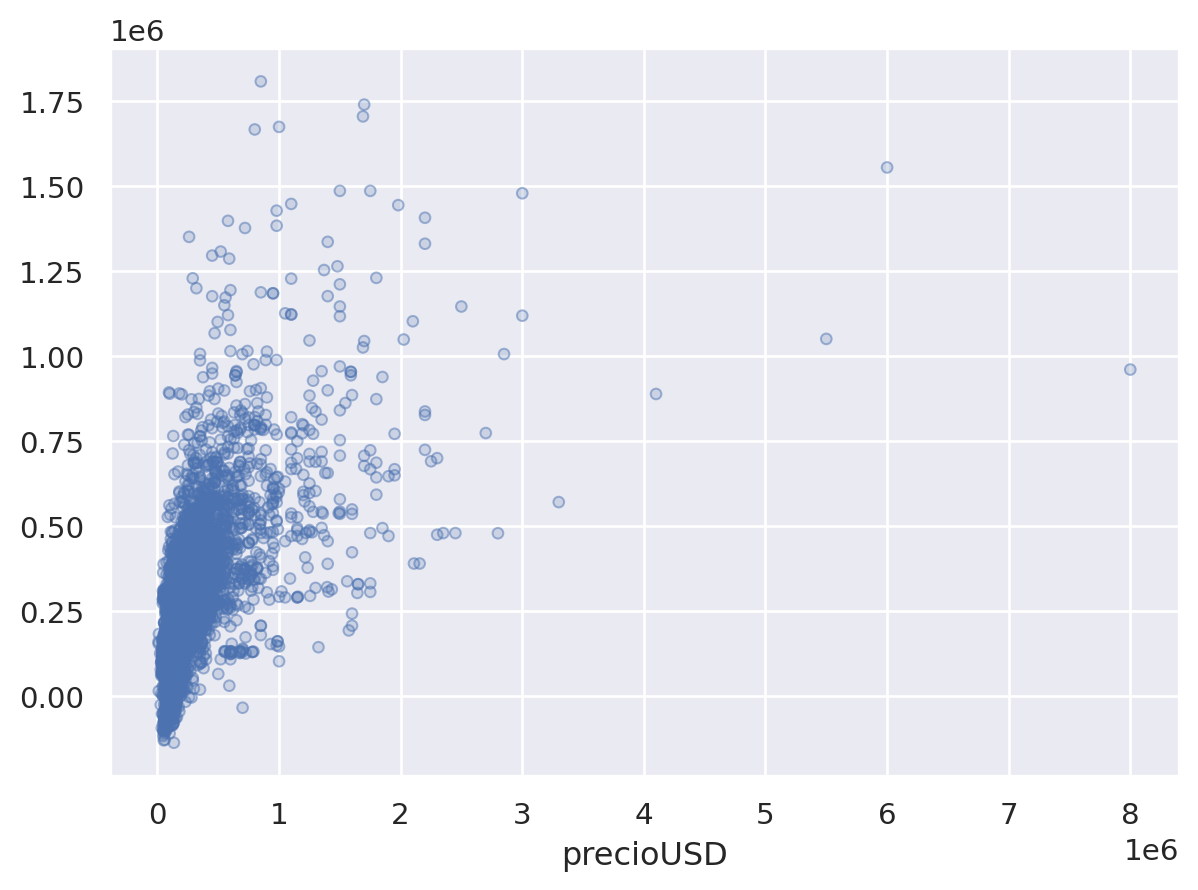

In [ ]:
##ploteo los datos de prueba con sus valores predichos por el modelo para tambien evaluar la calidad del modelo visualmente, si fuera perfecto seria solo la funcion identidad
so.Plot(x =y_test, y=y_pred).add(so.Dots(alpha=0.5))

##Evaluacion del modelo:
el grafico tiene una forma bastante lineal, y el R²=0.42 nos cuantifica que de Hecho tiene una forma bastante lineal por lo que el modelo predice de manera decente. el error cuadratico medio dio 55335333357 bastante elevado pero dado la naturaleza de los datos no nos indica un problema del modelo. por lo que hacer una regresion lineal para predecir el valor inmobiliario es una manera decente.  

##Clasificacion

Para la clasificacion solo usamos las columnas tipo_numeric,'sup_cub','sup_tot ,'lat','lon', y precioUSD por que provincia es lo que quiero clasificar, y ciudad,esta directamente relacionadas con la provincia, veremos si puede clasificar sin datos tan directos

In [ ]:
import pandas as pd
import numpy as np
##quiero clasificar si una provincia esta en la ciudad de buenos aires (amba+caba) o no, asi que transformo los datos categoricos asi
# Lista de provincias que queremos marcar como 1
provincias_objetivo = [
    'Capital Federal',
    'Bs.As. G.B.A. Zona Norte',
    'Bs.As. G.B.A. Zona Sur',
    'Bs.As. G.B.A. Zona Oeste'
]

# Crear variable binaria: 1 si está en las provincias objetivo, 0 si no
df_casas['es_objetivo'] = df_casas['provincia'].isin(provincias_objetivo).astype(int)


In [ ]:
# Variables predictoras (X)
X = df_casas[['tipo_numeric','sup_cub','sup_tot','lat','lon', 'precioUSD']]

# Variable objetivo (y)
y = df_casas['es_objetivo']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Crear y entrenar el modelo
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=5000)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Predicciones
y_pred = model.predict(X_test)

# Métricas
print(confusion_matrix(y_test, y_pred))



[[1158   82]
 [   4 5279]]


La matriz de confusion muestra que casi todos los datos cayeron en verdadero negativo y verdadero positivo por lo tanto el modelo puede clasificar bien, es una muestra de la calidad de la clasificacion.

#Consigna 2

In [ ]:

#Para descargar los archivos desde mi drive:

import gdown

file_id = '1O8ECsJtFHc78_44SmjaQuYA1ngdcPHD-'
file_id2 = '1MVp7u-cxw_F3GVW8ugno2jthxBaCgN9G'
# Construir el enlace de descarga
url = f'https://drive.google.com/uc?id={file_id}'
url2 = f'https://drive.google.com/uc?id={file_id2}'
# Descargar el archivo
gdown.download(url, 'wine-red.csv', quiet=False)
gdown.download(url2, 'wine-white.csv', quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1O8ECsJtFHc78_44SmjaQuYA1ngdcPHD-
To: /content/wine-red.csv
100%|██████████| 84.2k/84.2k [00:00<00:00, 13.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MVp7u-cxw_F3GVW8ugno2jthxBaCgN9G
To: /content/wine-white.csv
100%|██████████| 264k/264k [00:00<00:00, 5.41MB/s]


'wine-white.csv'

In [ ]:
#convierto los archivos csv en dataframes
import pandas as pd
df = pd.read_csv("wine-red.csv", encoding="latin1", sep=";")
df2 = pd.read_csv("wine-white.csv", encoding="latin1", sep=";")

In [ ]:
df2.head() ##veo cuales son las columnas y cantidad de datos
df.shape ##el vino blanco tiene mas datos, rojo tiene 1599 y el blanco 4898

(1599, 12)

voy a sacar la columna quality de los dataframes y juntarlos para ver si en el analisis de k means me los agrupa por quality y ntipo de vino  y en las direcciones favorecidas tengo que ver que tanto de cada variable tienen los nuevos autovectores y con eso puedo decir que estas features tienen mas info que las demas

In [ ]:
df_combinado = pd.concat([df, df2], ignore_index=True)

df_combinado.tail()
df2.tail()
df_combinado2 = pd.concat([df, df2], ignore_index=True)
df_combinado2 = df_combinado2.drop(columns=['quality'])
df_combinado2.shape

(6497, 11)

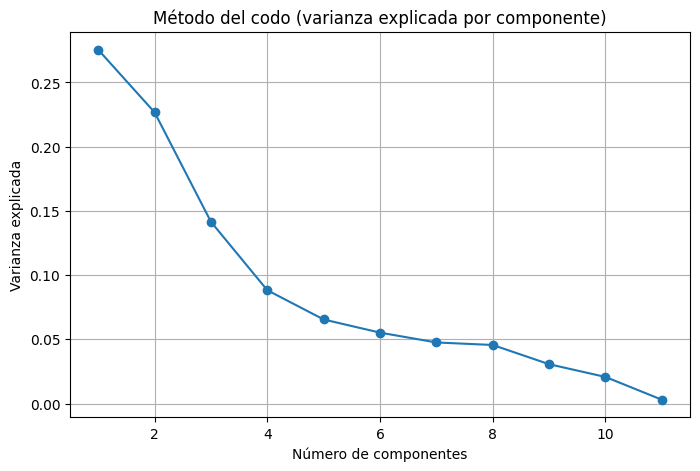

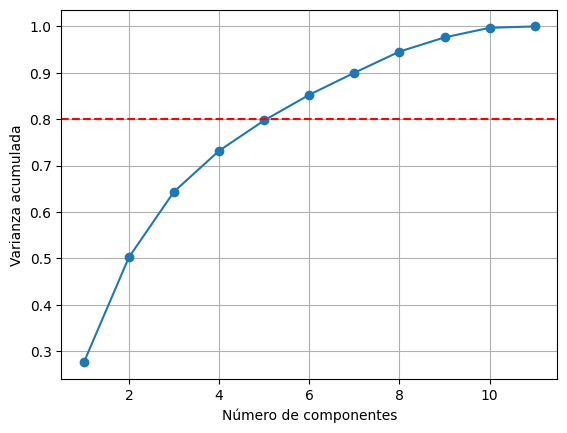

In [ ]:
#@title reduccion de dimensionalidad vino
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
df_std= StandardScaler().fit_transform(df_combinado2) ##rescalo los datos para que tengan todos la misma escala sino pca va a andar mal, me pone los datos con media=0 y desviacion=1
pca = PCA()
pca.fit(df_std)

explained_variance = pca.explained_variance_ratio_

# 4. Graficar la varianza explicada individual por componente
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Método del codo (varianza explicada por componente)")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada")
plt.grid(True)
plt.show()


cumulative_variance = np.cumsum(explained_variance) ##osea si uso 5 variables explico mas del 90% de la varianza
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.80, color='red', linestyle='--')
# plt.title("Varianza acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.grid(True)
plt.show()

In [ ]:
##hay que bajarlo a 5 componentes el vino, eso me explica el 80% de la varianza
##ahora bajo la dimensionalidad
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

df_escalado= StandardScaler().fit_transform(df_combinado2)
pca=PCA(n_components=5)
# Ajusto y transformo los datos
df_reducido = pca.fit_transform(df_escalado)

k=2, silhouette_score=0.2078
k=3, silhouette_score=0.3036
k=4, silhouette_score=0.2267
k=5, silhouette_score=0.1920
k=6, silhouette_score=0.1990
k=7, silhouette_score=0.2243
k=8, silhouette_score=0.1918
k=9, silhouette_score=0.1900
k=10, silhouette_score=0.1937


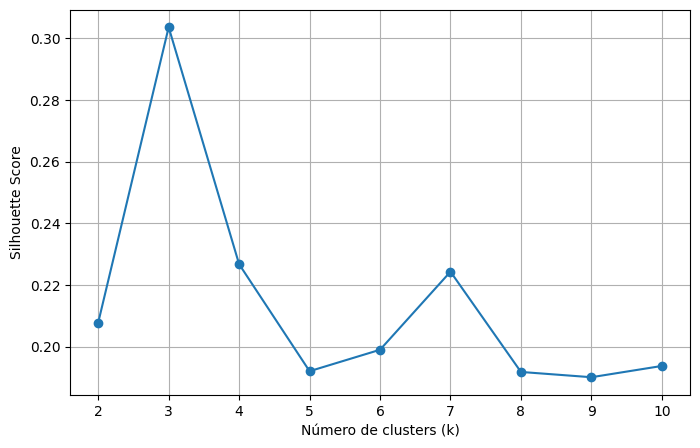

In [ ]:
## ##uso silouette y inercia para saber cuantos clusters usar
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Rango de k a probar
k_values = range(2, 11)  # de 2 a 10 clusters
scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(df_reducido)
    score = silhouette_score(df_reducido, labels)
    scores.append(score)
    print(f"k={k}, silhouette_score={score:.4f}")

# Graficar los resultados
plt.figure(figsize=(8, 5))
plt.plot(k_values, scores, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
#plt.title("Selección del número óptimo de clusters (KMeans + PCA)")
plt.grid(True)
plt.show()




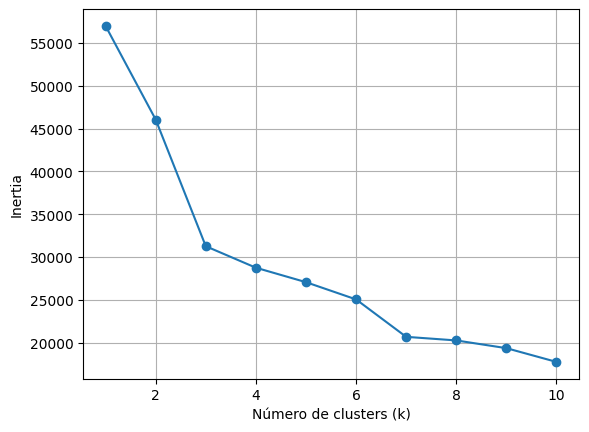

In [ ]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(df_reducido)
    inertias.append(kmeans.inertia_)

# Graficar
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inertia")
#plt.title("Método del codo para seleccionar k")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
##hago kmeans y me da una etiqueta para cada dato
kmeans = KMeans(n_clusters=7)

# Ajustás el modelo y asignás clusters a cada punto
labels = kmeans.fit_predict(df_reducido)

# labels es un array con la etiqueta de cluster para cada muestra
print(labels)

# Opcional: Ver los centroides en el espacio reducido
print("Centroides:\n", kmeans.cluster_centers_)
type(labels)



[2 2 2 ... 3 6 6]
Centroides:
 [[-4.09887204  4.71917287  0.87345594  3.34939191  4.18712046]
 [ 1.92782301  1.61132519 -0.39921365 -0.11435322 -0.20824119]
 [-2.52485756  0.19064961 -1.48278    -0.38589836  0.13248474]
 [ 0.36654311 -0.65702968  1.01660677 -0.67403389  0.30341771]
 [ 0.79310598 -0.26519371 -0.56631369  0.52765711  0.0981639 ]
 [-2.371953    1.50401849  1.5768606   0.28546954 -0.56739774]
 [ 0.03436856 -2.07566593  0.2751686   0.32169048 -0.10281099]]


numpy.ndarray

In [ ]:
##interpretacion:
##voy a sacar la columna quality de los dataframes y juntarlos para ver si en el analisis de k means me los agrupa
#por quality y ntipo de vino  y en las direcciones favorecidas tengo que ver que tanto de cada variable
#tienen los nuevos autovectores y con eso puedo decir que estas features tienen mas info que las demas o algo asi


###agrego a que cluster pertenece cada dato:
df_combinado["Cluster"]=labels
df_combinado

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,2
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,2
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,5
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,1
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,3
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,6


In [ ]:
df_combinado['Tipo_de_vino'] = ['R'] * 1599 + ['W'] * 4898 ##pongo una etiqueta para cada tipo de vino para el analisis, lo puedo hacer asi porque junte los dos dataframes en orden y se cuantas filas tenian

In [ ]:
df_combinado##dataframe con la separacion por vinos

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Cluster,Tipo_de_vino
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,2,R
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,2,R
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,R
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,5,R
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,2,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,6,W
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,1,W
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,3,W
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,6,W


In [ ]:
conteo_ok = df_combinado[df_combinado['Tipo_de_vino'] == "W"].groupby('Cluster').size()
print(conteo_ok)

conteo_ok2 = df_combinado[df_combinado['Tipo_de_vino'] == "R"].groupby('Cluster').size()
print(conteo_ok2)

Cluster
0       5
1    1368
2      46
3    1164
4    1139
5      24
6    1152
dtype: int64
Cluster
0     37
1      2
2    882
3      9
4     16
5    615
6     38
dtype: int64


In [ ]:
##el vino rojo tiene casi toda su presencia en los clusters 1 y 6, y un poquito en el 5 y casi nada en los demas
##el vino blanco tiene casi toda su presencia en los clusters 0 2 3 y 4 y  que son los de menor presencia del vino rojo, Y UN POQUITO EN EL 5
##BUEN RESULTADO PARA VER QUE TIPO DE VINO ES APARTIR DE SI CAE EN QUE CLUSTER
##CLUSTER 5 POCO DEFINITORIO

conteo_ok3 = df_combinado[df_combinado['quality'] == 3].groupby('Cluster').size()
print(conteo_ok3)

conteo_ok4 = df_combinado[df_combinado['quality'] == 4].groupby('Cluster').size()
print(conteo_ok4)
conteo_ok5 = df_combinado[df_combinado['quality'] == 5].groupby('Cluster').size()
print(conteo_ok5)

conteo_ok6 = df_combinado[df_combinado['quality'] == 6].groupby('Cluster').size()
print(conteo_ok6)
conteo_ok7 = df_combinado[df_combinado['quality'] == 7].groupby('Cluster').size()
print(conteo_ok7)

conteo_ok8 = df_combinado[df_combinado['quality'] == 8].groupby('Cluster').size()
print(conteo_ok8)
conteo_ok9 = df_combinado[df_combinado['quality'] == 9].groupby('Cluster').size()
print(conteo_ok9)
conteo_okk = df_combinado[df_combinado['quality'] == 2].groupby('Cluster').size()
print(conteo_okk)
##no me dice mucho

Cluster
0    1
1    7
2    7
3    5
4    3
5    4
6    3
dtype: int64
Cluster
0     2
1    24
2    63
3    59
4    35
5    16
6    17
dtype: int64
Cluster
0     26
1    616
2    471
3    362
4    363
5    198
6    102
dtype: int64
Cluster
0     12
1    592
2    344
3    531
4    564
5    267
6    526
dtype: int64
Cluster
0      1
1    109
2     41
3    176
4    164
5    140
6    448
dtype: int64
Cluster
1    21
2     2
3    40
4    26
5    14
6    90
dtype: int64
Cluster
1    1
6    4
dtype: int64
Series([], dtype: int64)


In [ ]:
##direcciones favorecidas
import pandas as pd

# Suponé que df tiene nombres de columnas
componentes = pd.DataFrame(
    pca.components_,
    columns=df_combinado2.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print(componentes)
##las que tienen mayor numero en modulo son las que mas aportan a la combinacion lineal.

     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
PC1      -0.238799         -0.380757     0.152388        0.345920  -0.290113   
PC2       0.336355          0.117550     0.183299        0.329914   0.315258   
PC3       0.434301         -0.307259     0.590570       -0.164688  -0.016679   
PC4      -0.164346         -0.212785     0.264300       -0.167443   0.244744   
PC5      -0.147480          0.151456    -0.155349       -0.353362   0.614391   

     free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
PC1             0.430914              0.487418 -0.044937 -0.218686  -0.294135   
PC2             0.071933              0.087266  0.584037 -0.155869   0.191716   
PC3            -0.134224             -0.107462 -0.175606 -0.455324   0.070042   
PC4             0.357279              0.208420 -0.072725  0.414551   0.640536   
PC5             0.223532              0.158134 -0.306561 -0.453376  -0.136577   

      alcohol  
PC1 -0.106437  
